In [1]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [4]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
import os

print(os.listdir())

['.config', 'Sample - Superstore.csv', 'sample_data']


In [6]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
from sklearn.model_selection import train_test_split

X = df[['Sales','Quantity','Discount']]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(32,
                activation='relu',
                input_shape=(3,)))

model.add(Dense(16,
                activation='relu'))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 62970.6250 - mae: 59.4357 - val_loss: 33774.2227 - val_mae: 51.3471
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 61338.1875 - mae: 55.4048 - val_loss: 31746.6914 - val_mae: 48.1300
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 58234.7305 - mae: 55.0422 - val_loss: 29240.5469 - val_mae: 50.4546
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54811.5586 - mae: 57.1535 - val_loss: 27206.0684 - val_mae: 52.8600
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 51723.9961 - mae: 59.2779 - val_loss: 25293.6055 - val_mae: 54.6938
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 48654.9297 - mae: 60.6869 - val_loss: 23451.9141 - val_mae: 56.0464
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 45530.3828 - mae: 60.5772 - val_loss: 21999.7754 - val_mae: 55.9028
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 42664.0000 - mae: 60.3935 - val_loss: 20323.

In [12]:
loss, mae = model.evaluate(
    X_test,
    y_test
)

print("Test MAE:", mae)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 80273.1484 - mae: 55.6931
Test MAE: 55.693111419677734


In [13]:
predictions = model.predict(X_test)

predictions[:10]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[ 18.507456 ],
       [ -3.2829475],
       [ 13.611018 ],
       [-20.730679 ],
       [ -1.4439777],
       [ -6.198203 ],
       [-55.90261  ],
       [ 12.330718 ],
       [-82.035286 ],
       [ -1.8294348]], dtype=float32)

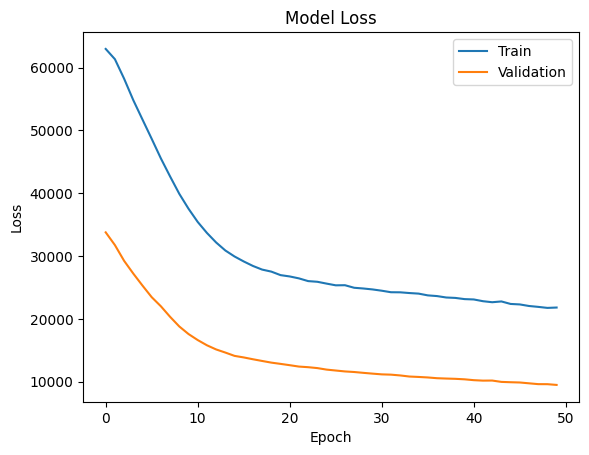

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

**Deep Learning Objective**

Predict profit using an Artificial Neural Network.

Current Losses Without Deep Learning,
Poor profit forecasting,
Incorrect pricing strategies,
Revenue leakage,
Loss-making transactions,
Benefits After Deep Learning,
More complex pattern recognition,
Improved prediction accuracy,
Better profit optimization,
Smarter business decisions